#### Dataset: Pima Indians Diabetes Dataset

#### Diabetes Prediction using XGBoost and Deep Learning (MLP)


- Step 1: Import / Load libraries and packages.

In [ ]:
#Import modules
import subprocess, sys

packages = [
    "xgboost",  #Gradient boosting model
    "tensorflow",  #Deep learning framework
    "scikit-learn",  #For utilities for ML like preprocessing, metrics and cross validation
    "imbalanced-learn",  #SMOTE for handling class imbalance
    "pandas",  #For data manipulation and analysis
    "numpy",  #For numerical Computation
    "matplotlib",  #Data Visualization
    "seaborn",  #Statistical Visualization
]

#Looping through each package
for pkg in packages:
    print(f"Installing {pkg}...") #Progress being shown
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

Installing xgboost...
Installing tensorflow...
Installing scikit-learn...
Installing imbalanced-learn...
Installing pandas...
Installing numpy...
Installing matplotlib...
Installing seaborn...


In [ ]:
import warnings, time, os #Package that handles warning so our code looks cleaner
warnings.filterwarnings("ignore") #Suppress warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3" #Only show fatal errors, hiding info messages, warnings and GPU logs
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0" #Disables intel OneDNN Optimizations to avoid inconsistent numerical results
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)

from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

- Step 2: Obtaining dataset shape to understand how many features we have.

In [ ]:
df = pd.read_csv(r"diabetes.csv")
print(f"\n[1] Dataset shape: {df.shape}")


[1] Dataset shape: (768, 9)


We have 768 rows and 9 columns (features).

- Step 3: Show the first five rows of dataset.

In [ ]:
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


We have 9 features ranging from number of pregnancies to outcome (if patient has diabetes or not).

In [ ]:
print(f"Class distribution:\n{df['Outcome'].value_counts().to_string()}")
#Using the outcome column to understand the class distribution

Class distribution:
Outcome
0    500
1    268


500 patients are non diabetic and 268 are diabetic.

In [ ]:
#Defining columns where the value of 0 is medically invalid
zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
#Replacing 0 with NaN
df[zero_cols] = df[zero_cols].replace(0, np.nan)


In [ ]:
#Replace all NaN in our dtaset with the median of each column
df.fillna(df.median(numeric_only=True), inplace=True)

In [ ]:
#Create a new feature (feature engineer) that combines blood sugar level (glucose) with body fat indicater (BMI)
df["Glucose_BMI"]   = df["Glucose"] * df["BMI"]

This feature captures interaction effect, high glucose and high BMI indicates stronger diabetes risk.

In [ ]:
#New feature that combines age and number of pregnancies
df["Age_Preg"]      = df["Age"] * df["Pregnancies"]

This feature shows that the older age and more pregnancies a woman has had, the higher risk she is of having diabetes.

In [ ]:
#New feature that creates a ratio, checking insulin relative to glucose level
df["Insulin_Glucose"] = df["Insulin"] / (df["Glucose"] + 1e-6) #1e-6 is used to prevent division by 0

- High insulin but low glucose may mean insulin resistance.

- Low insulin but high glucose means poor glucose regulation.

- Step 4: Train / Test split.

In [ ]:
X = df.drop("Outcome", axis=1).values #Drop outcome in our dataset
y = df["Outcome"].values #Assign outcome to y

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, #Test size is 20%, so training is 80%
    random_state=42, #Controls randomness of the split, ensures same split every code run
    stratify=y)
#Our dataset is imbalanced as more people are non diabetic, this ensures that the class distribution is preserved in train and test set

- Step 5: Scale data

In [ ]:
#Create a scaler that will transform data to have mean=0 and standard deviation=1
scaler = StandardScaler()

#Learns the mean and SD of each feature then applies scaling using learned values
X_train_sc = scaler.fit_transform(X_train)
#Will return scaled training data

#applies the mean and SD on the test data that were already calculated from training
X_test_sc  = scaler.transform(X_test)
#Returns scaled test set



- Step 6: Apply Synthetic Minotiy Oversampling Technique (SMOTE).
- Because the non diabetic class is more than the diabetic class, we use SMOTE to balance it. SMOTE creates a new artifical or synthetic minority examples based on existing minority samples. It helps balance the data.

In [ ]:
# SMOTE on training set only
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train_sc, y_train)
#Picks a real diabetic patient from our training data of outcome
#Then finds its nearest neighbors (other diabetic patients)
#Picks one neighbor randomly
#Creates a new patient somewhere between them (interpolates
#Repeats until diabetic class = non-diabetic class size
print(f"\n After SMOTE, the updated training samples: {len(X_res)}")


 After SMOTE, the updated training samples: 800


Our outcome was 800 training samples, meaning 400 are of class 0 and 400 are class 1. The class distribution is now balanced.

Use Extreme gradient boosting to build trees sequentially. Each tree boosts performance of the previous tree.This is our Machine Learning model.

- Step 7: Tuning XGBoost.
- To avoid overfitting and underfitting, we tune the hyperparameters of the XGBoost.

In [ ]:
#
print("\n Tuning XGBoost ...")
t0 = time.time() #Storing the current time in a variable called t0, to check how long XGBoost tuning/training takes.


 Tuning XGBoost ...


Now, we give our XGBoost hyperparameters.

In [ ]:
#set up hyperparameters to try
param_grid = {
    "n_estimators":      [200, 400], #number of trees XGBoost will build
    "max_depth":         [3, 5], #how deep each tree can grow
    "learning_rate":     [0.05, 0.1], #Learning rate controls how much each new tree contributes to the final prediction
    "subsample":         [0.8, 1.0], #percent of data used to build each tree
    "colsample_bytree":  [0.8, 1.0], #percent of features used to build each tree
    "min_child_weight":  [1, 3], #Minimum number of patients required in a leaf node

}

base_xgb = xgb.XGBClassifier(
    use_label_encoder=False, #XGBoost modle does not need to encode, our outcomes are already 0 and 1
    eval_metric="logloss", #Measures prediction error during training
    #LogLoss measures how wrong preditions are and how confident the model was
    random_state=42,
    n_jobs=-1 #Uses all your computer's CPU cores to train faster
)

- Step 8: Use strtaified cross validation to measure our model's prediction success or failure.
- StratifiedKFold helps every split or fold have the same ratio.

In [ ]:
#CV prepares 5-fold stratified cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(base_xgb, #GridSearchCV tries all parameter combinations, trains XGBoost over and over, evaluates and selects best performing setup
                    param_grid,
                    cv=cv, #Using the 5-fold cross validation we created earlier
                    scoring="f1", #Choose model with highest F-1 Score
                    n_jobs=-1,
                    verbose=0) #Mutes training messages

grid.fit(X_res, y_res) #GridSearch takes one parameter combination, performs our assigned CV, calculates F1-Score, repeats for all combinations
xgb_train_time = time.time() - t0 #Measuring training time

best_xgb = grid.best_estimator_ #Choosing the best model
print(f"Best parameters : {grid.best_params_}")
print(f"Training time: {xgb_train_time:.1f}s")

    Best params : {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 400, 'subsample': 0.8}
    Training time: 76.9s


- After testing many XGBoost configurations, our best performing setup has n_estimators = 400 (400 trees), max_depth = 5 (each tree can grow 5 levels deep), learning_rate = 0.1 (each tree contributes 10% strength when correcting mistakes), subsample = 0.8 (each tree trained on 80% of the training samples), colsample_bytree = 1.0 (every tree used all features), min_child_weight = 1 (trees were sllowed to split freely).
- Training time took 80 seconds to compute.

- Step 9: Evaluate XGBoost Model.

In [ ]:
t1 = time.time() #Checks how fast the modle predicts
xgb_preds = best_xgb.predict(X_test_sc) #Takes test features & outputs final class predictions
xgb_probs = best_xgb.predict_proba(X_test_sc)[:, 1] #Outputs probabilities, [:, 1 ]means take probability of class 1
xgb_test_time = time.time() - t1 #Ending time

xgb_acc  = accuracy_score(y_test, xgb_preds) #Evaluate accuracy
xgb_f1   = f1_score(y_test, xgb_preds) #F1-Score
xgb_auc  = roc_auc_score(y_test, xgb_probs) #AUC
xgb_params = len(best_xgb.get_booster().trees_to_dataframe()) #Counts structure of trained model

#Print all of the previous evaluations
print(f"\nXGBoost Results")
print(f"    Accuracy : {xgb_acc*100:.2f}%")
print(f"    F1-score : {xgb_f1:.4f}")
print(f"    AUC-ROC  : {xgb_auc:.4f}")
print(f"    Test time: {xgb_test_time*1000:.2f}ms")
print(f"    Num trees (depth nodes): {xgb_params}")


XGBoost Results
    Accuracy : 76.62%
    F1-score : 0.6786
    AUC-ROC  : 0.8126
    Test time: 7.96ms
    Num trees (depth nodes): 10078


- Step 10: Get classifiction report.

In [ ]:
print("\n" + classification_report(y_test, xgb_preds,
      target_names=["Non-Diabetic", "Diabetic"]))


              precision    recall  f1-score   support

Non-Diabetic       0.83      0.80      0.82       100
    Diabetic       0.66      0.70      0.68        54

    accuracy                           0.77       154
   macro avg       0.74      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154



- Step 11: Deep Learning Model Training

In [ ]:
print(" Training MLP Deep Learning model ...")
n_features = X_res.shape[1] #Gets number of input features, this tells neural network input size


 Training MLP Deep Learning model ...


- Step 12: Use Multilayer Perception, a kind of Neural Network

In [ ]:
def build_mlp(input_dim):
    """Deeper MLP with BatchNorm, Dropout, and L2 regularization."""
    model = Sequential([
        Dense(256, #First hidden layer with 256 neurons
              activation="relu", #ReLU Activation for nonlinear relationship
              kernel_regularizer=l2(1e-4), #L2 Regularization Prevejnts overfitting
              input_shape=(input_dim,)), #Number of features in dataset
        BatchNormalization(), #Normalizes output of previous layer & stabilizes training
        Dropout(0.4), #Randomly drops 40% of neurons during training to prevent high variance

        Dense(128, #Second hidden layer
              activation="relu",
              kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        Dropout(0.35),

        Dense(64, #Third hidden layer
              activation="relu",
              kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        Dropout(0.3),

        Dense(32, #Fourth hidden layer
              activation="relu",
              kernel_regularizer=l2(1e-4)),
        Dropout(0.2),

        Dense(1, activation="sigmoid") #Ouput later
    ])
    model.compile( #Model compilation
        optimizer=Adam(learning_rate=3e-4), #Adam is an optimizer that adjusts learning automatically to gradient descent
        loss="binary_crossentropy", #Compares predicted probability vs actual label, penalizes wrong confident predictions heavily
        metrics=["accuracy"] #Tracks how many predictions are correct
    )
    return model

- Step 13: Set-up stage before training neural network.

In [ ]:
tf.random.set_seed(42) #Fixes randomness in TensorFlow, ensures model behaves the same every run
mlp = build_mlp(n_features) #Creates full neural network, sets input size as number of features
mlp_total_params = mlp.count_params() #Counts all learable weights in the model
print(f"    Total trainable parameters: {mlp_total_params:,}")

callbacks = [ #Callbacks are rules that control training behaviour
    EarlyStopping(monitor="val_loss", #Watch training error
                  patience=30, #Wait 30 epochs before stopping
                  restore_best_weights=True, #Go back to the best version
                  verbose=0),

    ReduceLROnPlateau(monitor="val_loss", #If model stops improving, this will reduce learning rate
                      factor=0.5, #Halve the learing rate
                      patience=10,

                      min_lr=1e-6, #Will not go below 0.000001
                      verbose=0)
]


    Total trainable parameters: 48,129


Our MLP model is internally large and complex with 48,129 learnable weights and biases. The parameters grew very quickly because every neuron in the previous layer is used for every neuron in the the next layer, they are connected, therefore parameters grew very quickly.

- Step 14: Training steps of the neural network.

In [ ]:
t2 = time.time()
history = mlp.fit( #Training the model
    X_res, y_res, #This is the SMOTE balanced dataset
    validation_split=0.15, #15% of the training data is not used for training, only for checking performance
    epochs=300, #Model can see the data up to 300 times
    batch_size=32, #Model processes 32 samples at a time before updating weights
    callbacks=callbacks, #This connects to EarlySXtopping & ReduceLROnPlateau, stops training when model stops improving and reduces learning rate when stuck
    verbose=0
)
mlp_train_time = time.time() - t2 #End timer

In [ ]:
t3 = time.time()
mlp_probs = mlp.predict(X_test_sc, verbose=0).ravel() #Get probability of diabetes for each patient
mlp_preds = (mlp_probs >= 0.5).astype(int) #Convert probabilities into class labels (0 nand 1)
mlp_test_time = time.time() - t3 #How fast the model makes prediction on test data

mlp_acc = accuracy_score(y_test, mlp_preds)
mlp_f1  = f1_score(y_test, mlp_preds)
mlp_auc = roc_auc_score(y_test, mlp_probs)

- Step 15: Running our results after using neural networks.

In [ ]:
print(f"\nMLP Deep Learning Results")
print(f"    Accuracy : {mlp_acc*100:.2f}%")
print(f"    F1-score : {mlp_f1:.4f}")
print(f"    AUC-ROC  : {mlp_auc:.4f}")
print(f"    Training time: {mlp_train_time:.1f}s")
print(f"    Test time    : {mlp_test_time*1000:.2f}ms")
print(f"    Parameters   : {mlp_total_params:,}")


MLP Deep Learning Results
    Accuracy : 75.32%
    F1-score : 0.6481
    AUC-ROC  : 0.8215
    Training time: 61.9s
    Test time    : 281.34ms
    Parameters   : 48,129


In [ ]:
print("\n" + classification_report(y_test, mlp_preds,
      target_names=["Non-Diabetic", "Diabetic"]))


              precision    recall  f1-score   support

Non-Diabetic       0.81      0.81      0.81       100
    Diabetic       0.65      0.65      0.65        54

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



When comparing our results to the XGBoost neurla network, we find that XGBoost dominated most of the resulting scores like accuracy (0.7662), F1-Score (0.6786), and test time (24.6ms). Deep neural netorks worked better in AUC-ROC (0.8215) and training time (61.9s). XGBoost was slightly better in raw correctness with an accuracy of 76.62% over MLP with 75.32%.

- Step 16: Train data on different cross validation datasets.

In [ ]:
cv10 = StratifiedKFold(n_splits=10, #Split data into 10 different parts
                       shuffle=True,
                       random_state=42)

cv_scores = cross_val_score(best_xgb, #Already tuned best XGBoost model
                            X_train_sc,
                            y_train,
                             cv=cv10,
                            scoring="accuracy",
                            n_jobs=-1)

print(f"  10-Fold CV Accuracy: {cv_scores.mean()*100:.2f}% "
      f"(±{cv_scores.std()*100:.2f}%)")

  10-Fold CV Accuracy: 75.25% (±4.04%)


75.25% was the average accuracy across all 10 splits. Our modle predicted about 75 out of 100 patients correctly. The standard deviation being 4.04%. Our model accuracy changes based on which data split it is being trained on. Some datasets our model performed very well on (80%) and others as low as 72%.

In [ ]:
%matplotlib inline


- Step 17: Visualize Data results.

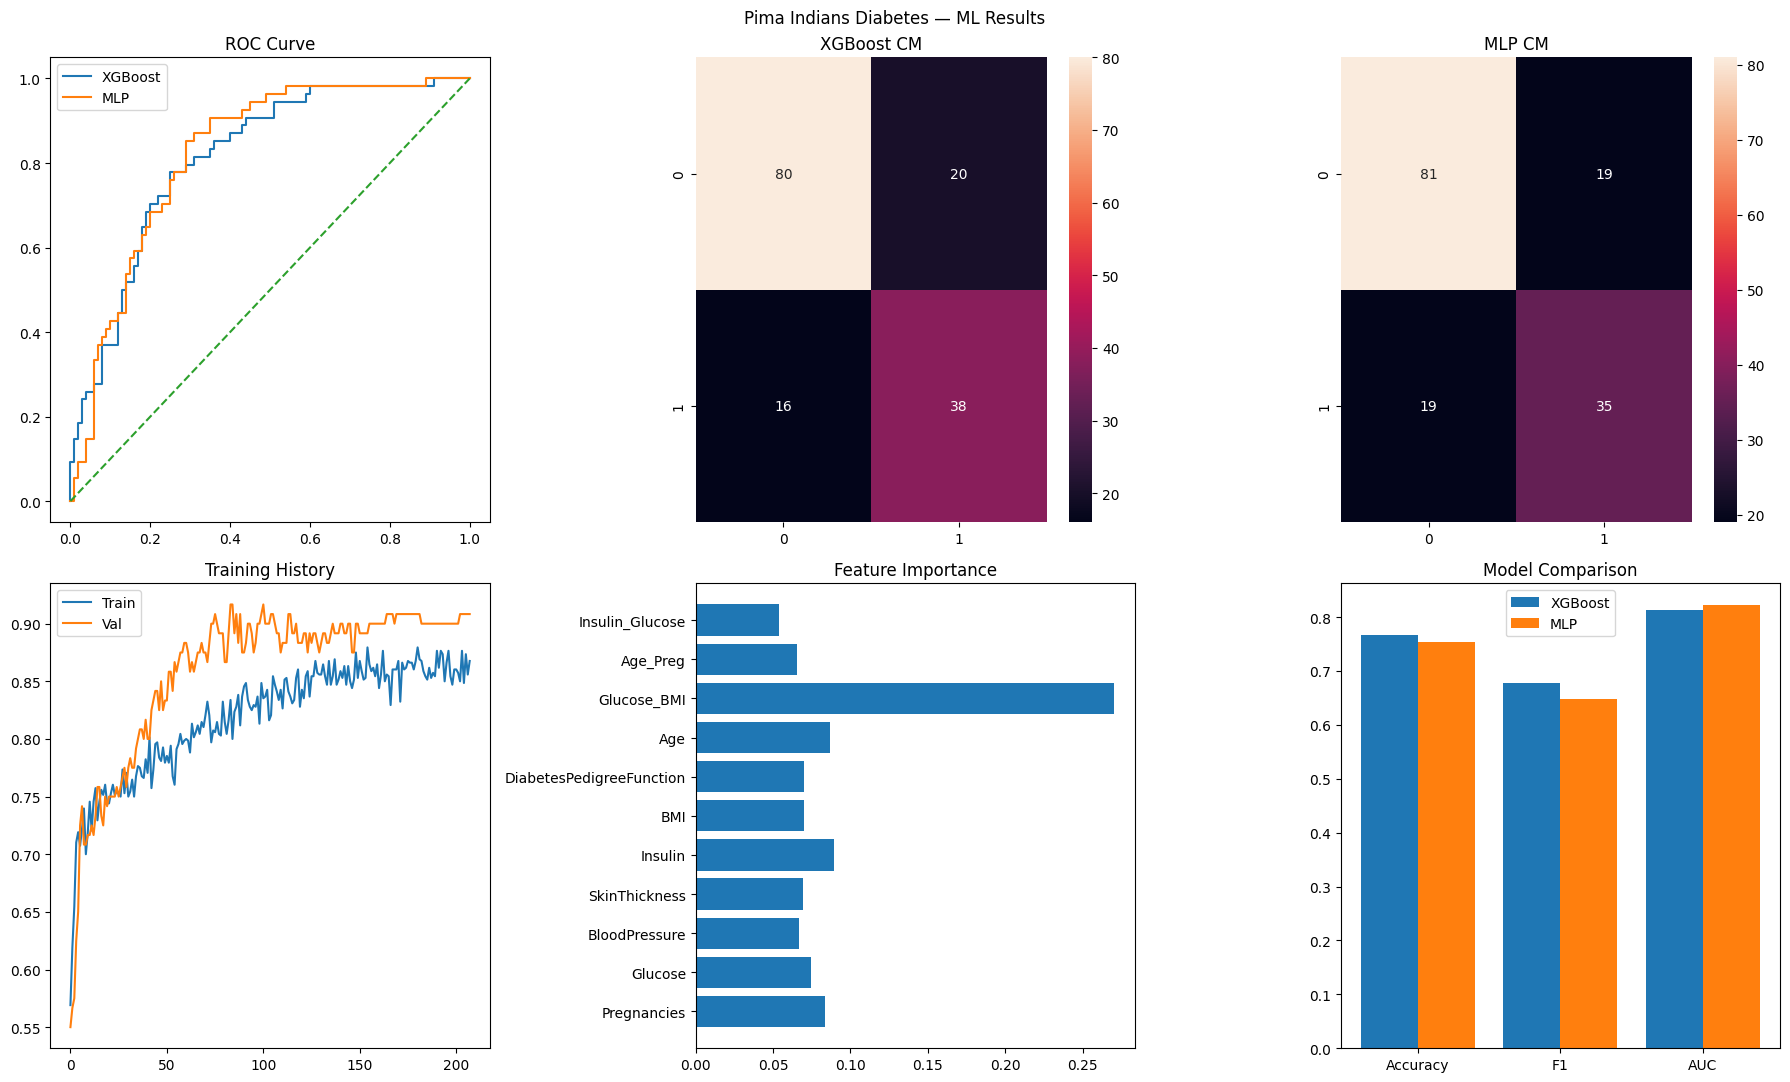

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11)) #Model Structure
fig.suptitle("Pima Indians Diabetes Results")

#ROC Curve
ax = axes[0, 0]

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, mlp_probs)

ax.plot(fpr_xgb, tpr_xgb, label="XGBoost")
ax.plot(fpr_mlp, tpr_mlp, label="MLP")
ax.plot([0, 1], [0, 1], "--")

ax.set_title("ROC Curve")
ax.legend()

#XGBoost Confusion Matrix
ax = axes[0, 1]
sns.heatmap(confusion_matrix(y_test, xgb_preds),
            annot=True, fmt="d", ax=ax)
ax.set_title("XGBoost CM")

#MLP Confusion Matrix
ax = axes[0, 2]
sns.heatmap(confusion_matrix(y_test, mlp_preds),
            annot=True, fmt="d", ax=ax)
ax.set_title("MLP CM")

#Training History
ax = axes[1, 0]
ax.plot(history.history["accuracy"], label="Train")
ax.plot(history.history["val_accuracy"], label="Val")
ax.set_title("Training History")
ax.legend()

#Feature Importance
ax = axes[1, 1]
importances = best_xgb.feature_importances_
features = df.drop("Outcome", axis=1).columns

ax.barh(features, importances)
ax.set_title("Feature Importance")

#Model Comparison
ax = axes[1, 2]

labels = ["Accuracy", "F1", "AUC"]
xgb_vals = [xgb_acc, xgb_f1, xgb_auc]
mlp_vals = [mlp_acc, mlp_f1, mlp_auc]

x = np.arange(len(labels))

ax.bar(x - 0.2, xgb_vals, 0.4, label="XGBoost")
ax.bar(x + 0.2, mlp_vals, 0.4, label="MLP")

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title("Model Comparison")
ax.legend()

plt.tight_layout()
plt.show()

1. ROC Curve
- Blue = XGBoost.
- Orange = MLP.
- Both curves are above diagonal which means they are good models.
- MLP is slightly higher in some regions, it is the best one.
- XGBoost however is very close, almost identical performance.

2. Confusion Matrices
- XGBoost:

* TN = 80
* FP = 20
* FN = 16
* TP = 38

- MLP:

* TN = 81
* FP = 19
* FN = 19
* TP = 35

- In medical fields, false negatives matter the most. XGboost was better because it had lower false negative results (16) than MLP (19). It also has better true positives (38) than MLP (35).

3. Training History.

- Train accuracy = blue.
- Validation accuracy = orange.
- This means as both curves increase, the model learns. The validation is slightly higher than training sometimes. No severe overfitting which is great.

4. Feature Importance
- Glucose_BMI dominates as the most important feature. This signifies that diabetes risk is mainly shown with glucose level and BMI interaction.

5. Model Comparison
- XGBoost performed better accuracy and F1-Score while AUC was performed better by MLP (slightly).
- XGboost is more balanced while MP is slightly better at ranking.

XGboost is the best model but only by a small differernce.

- Step 18: Compare Model Metric Results.

In [ ]:
print("FINAL SUMMARY")
print(f"{'Metric':<28} {'XGBoost':>12} {'MLP':>12}")
print(f"{'Accuracy':<28} {xgb_acc*100:>11.2f}% {mlp_acc*100:>11.2f}%")
print(f"{'F1-Score':<28} {xgb_f1:>12.4f} {mlp_f1:>12.4f}")
print(f"{'AUC-ROC':<28} {xgb_auc:>12.4f} {mlp_auc:>12.4f}")
print(f"{'Train Time (s)':<28} {xgb_train_time:>12.1f} {mlp_train_time:>12.1f}")
print(f"{'Test  Time (ms)':<28} {xgb_test_time*1000:>12.2f} {mlp_test_time*1000:>12.2f}")
print(f"{'Learnable Parameters':<28} {'N/A (trees)':>12} {mlp_total_params:>12,}")
print(f"\n10-Fold CV: {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%")

FINAL SUMMARY
Metric                            XGBoost          MLP
Accuracy                           76.62%       75.32%
F1-Score                           0.6786       0.6481
AUC-ROC                            0.8126       0.8215
Train Time (s)                       76.9         61.9
Test  Time (ms)                     24.60       281.34
Learnable Parameters          N/A (trees)       48,129

10-Fold CV: 75.25% ± 4.04%
